In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

In [2]:
from src.transforms import test_transforms
from src.dataset import ImageDataset
import torch

annot_path = Path("../data/preprocessed/trainval/annotations.csv")
img_dir = Path("../data/preprocessed/trainval/images")

# test dataset without transforms
dataset = ImageDataset(annot_path, img_dir)
transformed_dataset = ImageDataset(annot_path, img_dir, test_transforms)

In [3]:
image, labels = next(iter(dataset))
image.shape, labels.shape, image, labels

(torch.Size([3, 224, 224]),
 torch.Size([5, 5]),
 tensor([[[0.0039, 0.0039, 0.0039,  ..., 0.6549, 0.6549, 0.6549],
          [0.1176, 0.0980, 0.0627,  ..., 0.6510, 0.6431, 0.6392],
          [0.4235, 0.4078, 0.3647,  ..., 0.6667, 0.6627, 0.6588],
          ...,
          [0.1020, 0.1255, 0.1765,  ..., 0.2588, 0.2588, 0.2314],
          [0.1294, 0.1686, 0.2392,  ..., 0.2314, 0.2471, 0.2392],
          [0.1647, 0.2314, 0.3098,  ..., 0.2118, 0.2471, 0.2549]],
 
         [[0.0431, 0.0431, 0.0431,  ..., 0.7294, 0.7294, 0.7294],
          [0.1569, 0.1373, 0.1020,  ..., 0.7294, 0.7216, 0.7176],
          [0.4667, 0.4510, 0.4078,  ..., 0.7529, 0.7490, 0.7451],
          ...,
          [0.0275, 0.0157, 0.0000,  ..., 0.3176, 0.3098, 0.2745],
          [0.0353, 0.0471, 0.0471,  ..., 0.2902, 0.2980, 0.2824],
          [0.0627, 0.0980, 0.1098,  ..., 0.2706, 0.2980, 0.2980]],
 
         [[0.0471, 0.0471, 0.0471,  ..., 0.7529, 0.7529, 0.7529],
          [0.1608, 0.1412, 0.1059,  ..., 0.7569, 0.7490, 

In [4]:
transformed_image, labels = next(iter(transformed_dataset))
transformed_image.shape, labels.shape, transformed_image, labels

(torch.Size([3, 224, 224]),
 torch.Size([5, 5]),
 tensor([[[-2.1008, -2.1008, -2.1008,  ...,  0.7419,  0.7419,  0.7419],
          [-1.6042, -1.6898, -1.8439,  ...,  0.7248,  0.6906,  0.6734],
          [-0.2684, -0.3369, -0.5253,  ...,  0.7933,  0.7762,  0.7591],
          ...,
          [-1.6727, -1.5699, -1.3473,  ..., -0.9877, -0.9877, -1.1075],
          [-1.5528, -1.3815, -1.0733,  ..., -1.1075, -1.0390, -1.0733],
          [-1.3987, -1.1075, -0.7650,  ..., -1.1932, -1.0390, -1.0048]],
 
         [[-1.8431, -1.8431, -1.8431,  ...,  1.2206,  1.2206,  1.2206],
          [-1.3354, -1.4230, -1.5805,  ...,  1.2206,  1.1856,  1.1681],
          [ 0.0476, -0.0224, -0.2150,  ...,  1.3256,  1.3081,  1.2906],
          ...,
          [-1.9132, -1.9657, -2.0357,  ..., -0.6176, -0.6527, -0.8102],
          [-1.8782, -1.8256, -1.8256,  ..., -0.7402, -0.7052, -0.7752],
          [-1.7556, -1.5980, -1.5455,  ..., -0.8277, -0.7052, -0.7052]],
 
         [[-1.5953, -1.5953, -1.5953,  ...,  1.5420

In [5]:
from src.transforms import revert_normalization, revert_standardization

revert_standardization(transformed_image)
transformed_image = revert_normalization(transformed_image)
transformed_image

tensor([[[  0,   0,   0,  ..., 167, 167, 167],
         [ 29,  24,  15,  ..., 166, 164, 163],
         [108, 104,  93,  ..., 170, 169, 168],
         ...,
         [ 25,  31,  44,  ...,  66,  66,  58],
         [ 32,  42,  60,  ...,  58,  63,  60],
         [ 41,  58,  79,  ...,  53,  63,  64]],

        [[ 10,  10,  10,  ..., 186, 186, 186],
         [ 40,  35,  25,  ..., 186, 184, 183],
         [119, 115, 104,  ..., 192, 191, 190],
         ...,
         [  6,   3,   0,  ...,  81,  79,  70],
         [  8,  11,  11,  ...,  74,  76,  72],
         [ 15,  24,  27,  ...,  69,  76,  76]],

        [[ 11,  11,  11,  ..., 192, 192, 192],
         [ 41,  36,  26,  ..., 193, 191, 190],
         [121, 117, 106,  ..., 203, 202, 201],
         ...,
         [  2,   0,   1,  ..., 114, 111, 102],
         [  6,   9,  15,  ..., 107, 108, 104],
         [ 14,  23,  33,  ..., 102, 108, 108]]], dtype=torch.uint8)

In [6]:
image = revert_normalization(image)
image

tensor([[[  1,   1,   1,  ..., 167, 167, 167],
         [ 30,  25,  16,  ..., 166, 164, 163],
         [108, 104,  93,  ..., 170, 169, 168],
         ...,
         [ 26,  32,  45,  ...,  66,  66,  59],
         [ 33,  43,  61,  ...,  59,  63,  61],
         [ 42,  59,  79,  ...,  54,  63,  65]],

        [[ 11,  11,  11,  ..., 186, 186, 186],
         [ 40,  35,  26,  ..., 186, 184, 183],
         [119, 115, 104,  ..., 192, 191, 190],
         ...,
         [  7,   4,   0,  ...,  81,  79,  70],
         [  9,  12,  12,  ...,  74,  76,  72],
         [ 16,  25,  28,  ...,  69,  76,  76]],

        [[ 12,  12,  12,  ..., 192, 192, 192],
         [ 41,  36,  27,  ..., 193, 191, 190],
         [121, 117, 106,  ..., 203, 202, 201],
         ...,
         [  3,   1,   2,  ..., 114, 111, 102],
         [  7,  10,  16,  ..., 107, 108, 104],
         [ 15,  24,  33,  ..., 102, 108, 108]]], dtype=torch.uint8)

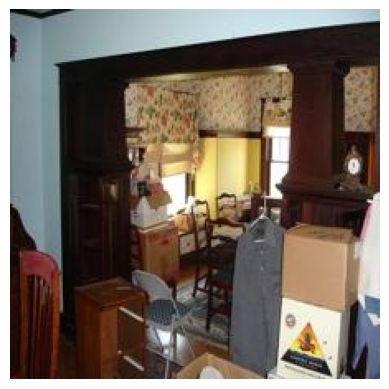

In [7]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()

ax.imshow(image.permute(1, 2, 0))
ax.axis(False)

plt.show()

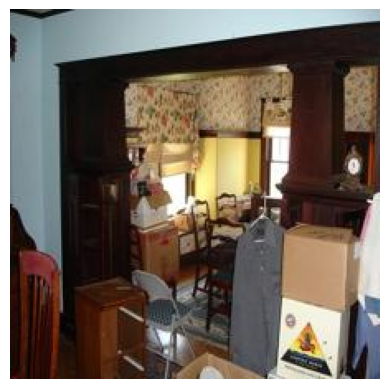

In [8]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()

ax.imshow(transformed_image.permute(1, 2, 0))
ax.axis(False)

plt.show()

In [10]:
from src.utilities import convert_xywh_coordinates
from src.configs import IDX_TO_CLASS

converted_bboxes = []
class_labels = []

for label in labels:
    converted_bboxes.append(convert_xywh_coordinates(label[1:], True))
    class_labels.append(IDX_TO_CLASS[int(label[0])])

converted_bboxes, class_labels

([(118, 126, 144, 202),
  (74, 158, 114, 222),
  (2, 146, 30, 224),
  (108, 116, 132, 178),
  (124, 111, 140, 131)],
 ['chair', 'chair', 'chair', 'chair', 'chair'])

In [ ]:
from matplotlib import pyplot as plt
from src.visualization import draw_rectangles

fig, ax = plt.subplots(1, figsize=(8, 8))

image = draw_rectangles(image, c, labels)

ax.imshow(image)
ax.axis(False)

plt.show()